In [94]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [95]:
# Input file
suffix = "m10k"
file_path = "metrics/spark_stream_metrics_q11.json"
directory = "figures/figures_" + suffix + "/"

# Output directory
os.makedirs(directory, exist_ok=True)

In [96]:
pwd

'/Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/spark'

In [97]:
# ---- read JSON lines ----
data = []
with open(file_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# ---------------------------------------
# OPTIONAL: remove idle batches
# ---------------------------------------
df = df[df["numInputRows"] > 0]


In [98]:
# ---------------------------------------
# Keep only "level" (steady-state) region
# (robust percentile filtering)
# ---------------------------------------
#lower = df["throughput_rps"].quantile(0.1)
#upper = df["throughput_rps"].quantile(0.9)

#df = df[
#    (df["throughput_rps"] >= lower) &
#    (df["throughput_rps"] <= upper)
#]

# Re-sort after filtering (important)
df = df.sort_values("timestamp").reset_index(drop=True)

# Recompute time again AFTER dropping NaNs
df["time_sec"] = (
    df["timestamp"] - df["timestamp"].min()
).dt.total_seconds()


In [99]:
cut_index = int(len(df) * 0.6)
df = df.iloc[cut_index:].reset_index(drop=True)

In [100]:
# ---------------------------------------
# Convert time → seconds from start
# ---------------------------------------
df["time_sec"] = (df["timestamp"] - df["timestamp"].min()).dt.total_seconds()

# ---------------------------------------
# Rolling smoothing (window = 5 points)
# ---------------------------------------
ROLLING_WINDOW = 2

In [101]:
df["p50_smooth"] = df["p50_latency_ms"].rolling(ROLLING_WINDOW).mean()
df["p95_smooth"] = df["p95_latency_ms"].rolling(ROLLING_WINDOW).mean()
df["p99_smooth"] = df["p99_latency_ms"].rolling(ROLLING_WINDOW).mean()
df["avg_smooth"] = df["avg_latency_ms"].rolling(ROLLING_WINDOW).mean()


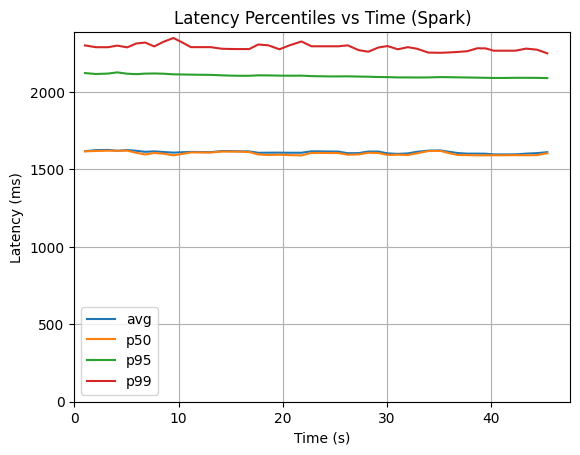

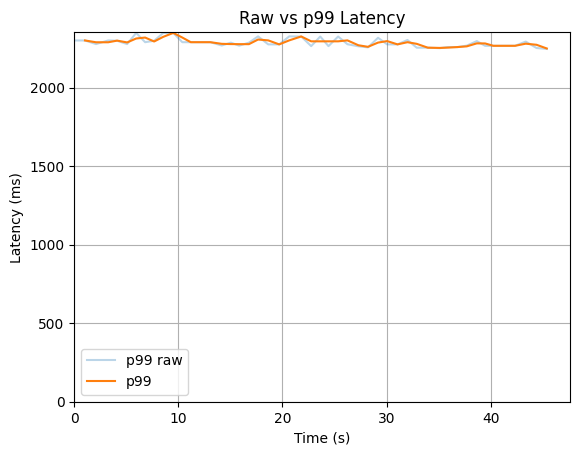

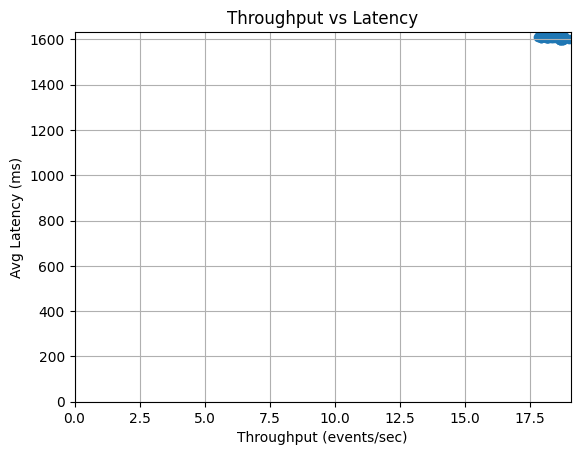

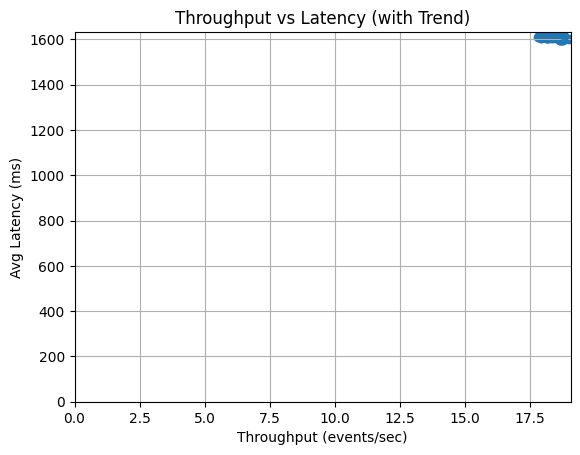

Correlation (throughput vs latency): -0.4790


In [102]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle this if you want plots to appear
SHOW_PLOTS = True

# Ensure output directory exists
os.makedirs(directory, exist_ok=True)

# ---------------------------------------
# 1. Smoothed latency percentiles
# ---------------------------------------
plt.figure()

plt.plot(
    df["time_sec"],
    df["avg_smooth"],
    label="avg"
)
plt.plot(df["time_sec"], df["p50_smooth"], label="p50")
plt.plot(df["time_sec"], df["p95_smooth"], label="p95")
plt.plot(df["time_sec"], df["p99_smooth"], label="p99")


plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")
plt.title("Latency Percentiles vs Time (Spark)")
plt.legend()
plt.grid(True)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.savefig(directory + "latency_percentiles_smoothed.png", dpi=300, bbox_inches="tight")

if SHOW_PLOTS:
    plt.show()

plt.close()


# ---------------------------------------
# 2. Raw vs smoothed p99
# ---------------------------------------
plt.figure()

plt.plot(df["time_sec"], df["p99_latency_ms"], alpha=0.3, label="p99 raw")
plt.plot(df["time_sec"], df["p99_smooth"], label="p99")

plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")
plt.title("Raw vs p99 Latency")
plt.legend()
plt.grid(True)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.savefig(directory + "p99_raw_vs_smoothed.png", dpi=300, bbox_inches="tight")

if SHOW_PLOTS:
    plt.show()

plt.close()


# ---------------------------------------
# 3. Throughput vs latency (scatter)
# ---------------------------------------
plt.figure()

plt.scatter(df["throughput_rps"], df["avg_latency_ms"])

plt.xlabel("Throughput (events/sec)")
plt.ylabel("Avg Latency (ms)")
plt.title("Throughput vs Latency")
plt.grid(True)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.savefig(directory + "throughput_vs_latency.png", dpi=300, bbox_inches="tight")

if SHOW_PLOTS:
    plt.show()

plt.close()


# ---------------------------------------
# 4. Trend line (correlation)
# ---------------------------------------
plt.figure()

x = df["throughput_rps"]
y = df["avg_latency_ms"]

plt.scatter(x, y)

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
plt.plot(x, trend(x), linestyle="--")

plt.xlabel("Throughput (events/sec)")
plt.ylabel("Avg Latency (ms)")
plt.title("Throughput vs Latency (with Trend)")
plt.grid(True)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.savefig(directory + "throughput_vs_latency_trend.png", dpi=300, bbox_inches="tight")

if SHOW_PLOTS:
    plt.show()

plt.close()


# ---------------------------------------
# 5. Correlation value
# ---------------------------------------
correlation = df["throughput_rps"].corr(df["avg_latency_ms"])
print(f"Correlation (throughput vs latency): {correlation:.4f}")